# Clase 7 MG

In [1]:
## Librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


## Breast Cancer (METABRIC, Nature 2012 & Nat Commun 2016)




Origen del dataset (https://www.cbioportal.org/study/clinicalData?id=brca_metabric)

La base de datos del Consorcio Internacional de Taxonomía Molecular del Cáncer de Mama (METABRIC) es un proyecto Canadá-Reino Unido que contiene datos de secuenciación específica de 1980 muestras primarias de cáncer de mama. Los datos clínicos y genómicos se descargaron de cBioPortal.

El conjunto de datos fue recopilado por el profesor Carlos Caldas del Cambridge Research Institute y el profesor Sam Aparicio del British Columbia Cancer Center en Canadá y publicado en Nature Communications (Pereira et al., 2016). También apareció en varios artículos, incluidos Nature y otros:
- [Associations between genomic stratification of breast cancer and centrally reviewed tumor pathology in the METABRIC cohort](https://www.nature.com/articles/s41523-018-0056-8)
- [Predicting Outcomes of Hormone and Chemotherapy in the Molecular Taxonomy of Breast Cancer International Consortium (METABRIC) Study by Biochemically-inspired Machine Learning](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5461908/)

## Desde CBioPortal:

- Clinical attributes in the dataset: 31 values
- Genetic attributes in the dataset: The genetics part of the dataset contains m-RNA levels z-score for 331 genes, and mutation for 175 genes.

### Genetic attributes in the dataset:

| Name                           | Type   | Description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| ------------------------------ | ------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| patient_id                     | object | Patient ID                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| age_at_diagnosis               | float  | Age of the patient at diagnosis time                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| type_of_breast_surgery         | object | Breast cancer surgery type: 1- MASTECTOMY, which refers to a surgery to remove all breast tissue from a breast as a way to treat or prevent breast cancer. 2- BREAST CONSERVING, which refers to a urgery where only the part of the breast that has cancer is removed                                                                                                                                                                                                                             |
| cancer_type                    | object | Breast cancer types: 1- Breast Cancer or 2- Breast Sarcoma                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| cancer_type_detailed           | object | Detailed Breast cancer types: 1- Breast Invasive Ductal Carcinoma 2- Breast Mixed Ductal and Lobular Carcinoma 3- Breast Invasive Lobular Carcinoma 4- Breast Invasive Mixed Mucinous Carcinoma 5- Metaplastic Breast Cancer                                                                                                                                                                                                                                                                       |
| cellularity                    | object | Cancer cellularity post chemotherapy, which refers to the amount of tumor cells in the specimen and their arrangement into clusters                                                                                                                                                                                                                                                                                                                                                                |
| chemotherapy                   | int    | Whether or not the patient had chemotherapy as a treatment (yes/no)                                                                                                                                                                                                                                                                                                                                                                                                                                |
| pam50_+_claudin-low_subtype    | object | Pam 50: is a tumor profiling test that helps show whether some estrogen receptor-positive (ER-positive), HER2-negative breast cancers are likely to metastasize (when breast cancer spreads to other organs). The claudin-low breast cancer subtype is defined by gene expression characteristics, most prominently: Low expression of cell–cell adhesion genes, high expression of epithelial–mesenchymal transition (EMT) genes, and stem cell-like/less differentiated gene expression patterns |
| cohort                         | float  | Cohort is a group of subjects who share a defining characteristic (It takes a value from 1 to 5)                                                                                                                                                                                                                                                                                                                                                                                                   |
| er_status_measured_by_ihc      | float  | To assess if estrogen receptors are expressed on cancer cells by using immune-histochemistry (a dye used in pathology that targets specific antigen, if it is there, it will give a color, it is not there, the tissue on the slide will be colored) (positive/negative)                                                                                                                                                                                                                           |
| er_status                      | object | Cancer cells are positive or negative for estrogen receptors                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| neoplasm_histologic_grade      | int    | Determined by pathology by looking the nature of the cells, do they look aggressive or not (It takes a value from 1 to 3)                                                                                                                                                                                                                                                                                                                                                                          |
| her2_status_measured_by_snp6   | object | To assess if the cancer positive for HER2 or not by using advance molecular techniques (Type of next generation sequencing)                                                                                                                                                                                                                                                                                                                                                                        |
| her2_status                    | object | Whether the cancer is positive or negative for HER2                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| tumor_other_histologic_subtype | object | Type of the cancer based on microscopic examination of the cancer tissue (It takes a value of 'Ductal/NST', 'Mixed', 'Lobular', 'Tubular/ cribriform', 'Mucinous', 'Medullary', 'Other', 'Metaplastic' )                                                                                                                                                                                                                                                                                           |
| hormone_therapy                | int    | Whether or not the patient had hormonal as a treatment (yes/no)                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| inferred_menopausal_state      | object | Whether the patient is is post menopausal or not (post/pre)                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| integrative_cluster            | object | Molecular subtype of the cancer based on some gene expression (It takes a value from '4ER+', '3', '9', '7', '4ER-', '5', '8', '10', '1', '2', '6')                                                                                                                                                                                                                                                                                                                                                 |
| primary_tumor_laterality       | object | Whether it is involving the right breast or the left breast                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| lymph_nodes_examined_positive  | float  | To take samples of the lymph node during the surgery and see if there were involved by the cancer                                                                                                                                                                                                                                                                                                                                                                                                  |
| mutation_count                 | float  | Number of gene that has relevant mutations                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| nottingham_prognostic_index    | float  | It is used to determine prognosis following surgery for breast cancer. Its value is calculated using three pathological criteria: the size of the tumour; the number of involved lymph nodes; and the grade of the tumour.                                                                                                                                                                                                                                                                         |
| oncotree_code                  | object | The OncoTree is an open-source ontology that was developed at Memorial Sloan Kettering Cancer Center (MSK) for standardizing cancer type diagnosis from a clinical perspective by assigning each diagnosis a unique OncoTree code.                                                                                                                                                                                                                                                                 |
| overall_survival_months        | float  | Duration from the time of the intervention to death                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| overall_survival               | object | Target variable wether the patient is alive of dead.                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| pr_status                      | object | Cancer cells are positive or negative for progesterone receptors                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| radio_therapy                  | int    | Whether or not the patient had radio as a treatment (yes/no)                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| 3-gene_classifier_subtype      | object | Three Gene classifier subtype It takes a value from 'ER-/HER2-', 'ER+/HER2- High Prolif', nan, 'ER+/HER2- Low Prolif','HER2+'                                                                                                                                                                                                                                                                                                                                                                      |
| tumor_size                     | float  | Tumor size measured by imaging techniques                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| tumor_stage                    | float  | Stage of the cancer based on the involvement of surrounding structures, lymph nodes and distant spread                                                                                                                                                                                                                                                                                                                                                                                             |
| death_from_cancer              | int    | Wether the patient's death was due to cancer or not (yes/no)                                                                                                                                                                                                                                                                                                                                                                                                                                       |


### Genetic attributes in the dataset:
The genetics part of the dataset contains m-RNA levels z-score for 331 genes, and mutation for 175 genes.

#### What are mRNA?
The DNA molecules attached to each slide act as probes to detect gene expression, which is also known as the transcriptome or the set of messenger RNA (mRNA) transcripts expressed by a group of genes. To perform a microarray analysis, mRNA molecules are typically collected from both an experimental sample and a reference sample.

#### What are mRNA Z-Scores?
For mRNA expression data, The calculations of the relative expression of an individual gene and tumor to the gene's expression distribution in a reference population is done. That reference population is all samples in the study . The returned value indicates the number of standard deviations away from the mean of expression in the reference population (Z-score). This measure is useful to determine whether a gene is up- or down-regulated relative to the normal samples or all other tumor samples.

The formula is :
```
z = (expression in tumor sample - mean expression in reference sample) / standard deviation of expression in reference sample
```

## Exploratory Data Analysis (EDA)

### Cargando la data

In [2]:
data = pd.read_csv("METABRIC_RNA_Mutation.csv")

C:\Users\marit\AppData\Local\Temp\ipykernel_2364\371503695.py:1: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("METABRIC_RNA_Mutation.csv")


In [3]:
## dimensiones del data set (<filas>, <columnas>)
data.shape

(1904, 693)

In [4]:
## head()
data.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


### Explorando la data clinica

In [5]:
columnas_data_clinica = data.columns[:31]
print(columnas_data_clinica)

Index(['patient_id', 'age_at_diagnosis', 'type_of_breast_surgery',
       'cancer_type', 'cancer_type_detailed', 'cellularity', 'chemotherapy',
       'pam50_+_claudin-low_subtype', 'cohort', 'er_status_measured_by_ihc',
       'er_status', 'neoplasm_histologic_grade',
       'her2_status_measured_by_snp6', 'her2_status',
       'tumor_other_histologic_subtype', 'hormone_therapy',
       'inferred_menopausal_state', 'integrative_cluster',
       'primary_tumor_laterality', 'lymph_nodes_examined_positive',
       'mutation_count', 'nottingham_prognostic_index', 'oncotree_code',
       'overall_survival_months', 'overall_survival', 'pr_status',
       'radio_therapy', '3-gene_classifier_subtype', 'tumor_size',
       'tumor_stage', 'death_from_cancer'],
      dtype='object')


In [6]:
data_clinica = data[columnas_data_clinica].copy()

In [7]:
data_clinica.shape

(1904, 31)

In [8]:
data_clinica.head()

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,6.044,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,4.020,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,4.030,IDC,163.700000,0,Positive,0,NaN,15.0,2.0,Died of Disease
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,4.050,MDLC,164.933333,1,Positive,1,NaN,25.0,2.0,Living
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,6.080,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease


#### info()
Imprime un listado de columnas, cuantos valores no nulos contiene y el tipo de objeto

In [9]:
data_clinica.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1904 entries, 0 to 1903
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      1904 non-null   int64  
 1   age_at_diagnosis                1904 non-null   float64
 2   type_of_breast_surgery          1882 non-null   object 
 3   cancer_type                     1904 non-null   object 
 4   cancer_type_detailed            1889 non-null   object 
 5   cellularity                     1850 non-null   object 
 6   chemotherapy                    1904 non-null   int64  
 7   pam50_+_claudin-low_subtype     1904 non-null   object 
 8   cohort                          1904 non-null   float64
 9   er_status_measured_by_ihc       1874 non-null   object 
 10  er_status                       1904 non-null   object 
 11  neoplasm_histologic_grade       1832 non-null   float64
 12  her2_status_measured_by_snp6    19

#### describe()
Estadistica descriptiva de los valos numericos en el dataframe

In [10]:
data_clinica.describe()

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,overall_survival,radio_therapy,tumor_size,tumor_stage
count,1904.000000,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,1904.000000,1904.000000,1884.000000,1403.000000
mean,3921.982143,61.087054,0.207983,2.643908,2.415939,0.616597,2.002101,5.697687,4.033019,125.121324,0.420693,0.597164,26.238726,1.750535
std,2358.478332,12.978711,0.405971,1.228615,0.650612,0.486343,4.079993,4.058778,1.144492,76.334148,0.493800,0.490597,15.160976,0.628999
min,0.000000,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,896.500000,51.375000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,60.825000,0.000000,0.000000,17.000000,1.000000
50%,4730.500000,61.770000,0.000000,3.000000,3.000000,1.000000,0.000000,5.000000,4.042000,115.616667,0.000000,1.000000,23.000000,2.000000
75%,5536.250000,70.592500,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.040250,184.716667,1.000000,1.000000,30.000000,2.000000
max,7299.000000,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,355.200000,1.000000,1.000000,182.000000,4.000000


#### Variable Objetivo

In [11]:
data_clinica['overall_survival'].unique()

array([1, 0], dtype=int64)

# Clasificador

In [12]:
from sklearn.linear_model import LogisticRegression

In [13]:
#eliminamos filas que contienen valores nulos
data_clinica.dropna(inplace=True)

In [14]:
data_clinica.shape

(1092, 31)

In [15]:
data_clinica.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1092 entries, 1 to 1664
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   patient_id                      1092 non-null   int64  
 1   age_at_diagnosis                1092 non-null   float64
 2   type_of_breast_surgery          1092 non-null   object 
 3   cancer_type                     1092 non-null   object 
 4   cancer_type_detailed            1092 non-null   object 
 5   cellularity                     1092 non-null   object 
 6   chemotherapy                    1092 non-null   int64  
 7   pam50_+_claudin-low_subtype     1092 non-null   object 
 8   cohort                          1092 non-null   float64
 9   er_status_measured_by_ihc       1092 non-null   object 
 10  er_status                       1092 non-null   object 
 11  neoplasm_histologic_grade       1092 non-null   float64
 12  her2_status_measured_by_snp6    10

In [16]:
#Seleccionar unas variables numéricas para el ejemplo
variables = [
    "age_at_diagnosis", "chemotherapy", "lymph_nodes_examined_positive", "lymph_nodes_examined_positive",
    "radio_therapy", "tumor_size", "tumor_stage"
]

In [17]:
x = data_clinica[variables]
y = data_clinica['overall_survival']

### Definicion del Modelo

In [18]:
modelo = LogisticRegression()

In [19]:
modelo.fit(x,y)

LogisticRegression()

### Realizando una Prediccion

In [20]:
#Este sample es aleatorio
paciente_random = data_clinica.sample(n=1)

In [21]:
paciente_random

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
1488,5638,65.14,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumA,3.0,Positve,...,3.04,IDC,195.7,0,Positive,1,ER+/HER2- High Prolif,20.0,1.0,Died of Other Causes


In [22]:
modelo.predict(paciente_random[variables])

array([0], dtype=int64)

In [23]:
paciente_random['overall_survival']

1488    0
Name: overall_survival, dtype: int64

In [24]:
#Ahora con varios pacientes
pacientes_random = data_clinica.sample(n=10)

In [25]:
pacientes_random

,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,nottingham_prognostic_index,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer
1411,5511,54.18,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,Her2,3.0,Negative,...,4.040,IDC,158.966667,1,Positive,0,ER-/HER2-,20.0,1.0,Living
1471,5605,40.37,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,3.0,Positve,...,3.050,IDC,123.700000,1,Positive,1,ER+/HER2- High Prolif,25.0,2.0,Living
538,2791,40.79,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,2.0,Positve,...,3.034,IDC,271.933333,1,Positive,1,ER+/HER2- Low Prolif,17.0,1.0,Living
1281,5308,67.62,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Low,0,Normal,3.0,Positve,...,4.050,IDC,104.766667,0,Positive,1,ER+/HER2- Low Prolif,25.0,2.0,Died of Disease
1493,5646,58.40,BREAST CONSERVING,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,0,LumB,3.0,Positve,...,4.060,MDLC,167.100000,0,Negative,1,ER+/HER2- High Prolif,30.0,2.0,Died of Other Causes
918,4686,53.03,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumA,3.0,Positve,...,5.070,IDC,48.433333,0,Negative,1,ER+/HER2- Low Prolif,35.0,2.0,Died of Disease
362,528,53.64,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,1,LumA,1.0,Positve,...,5.052,IDC,193.966667,1,Negative,1,ER+/HER2- Low Prolif,26.0,2.0,Living
890,4640,61.59,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,Her2,3.0,Negative,...,4.050,IDC,200.600000,1,Negative,1,ER+/HER2- High Prolif,25.0,2.0,Living
495,2632,36.52,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,Her2,2.0,Negative,...,5.030,IDC,19.100000,0,Negative,1,HER2+,15.0,2.0,Died of Disease
226,361,40.50,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,Her2,1.0,Negative,...,6.048,IDC,15.066667,0,Negative,0,HER2+,24.0,2.0,Died of Other Causes


In [26]:
modelo.predict(pacientes_random[variables])

array([0, 1, 1, 0, 1, 1, 1, 1, 1, 0], dtype=int64)

In [27]:
pacientes_random['overall_survival']

1411    1
1471    1
538     1
1281    0
1493    0
918     0
362     1
890     1
495     0
226     0
Name: overall_survival, dtype: int64

In [28]:
modelo.coef_

array([[-0.0519794 , -0.18204223, -0.05103597, -0.05103597,  0.61599618,
        -0.02420226,  0.06364232]])

## Evaluando el Modelo

In [29]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve

In [30]:
predicciones = modelo.predict(data_clinica[variables])

In [31]:
predicciones.shape

(1092,)

In [32]:
accuracy_score(predicciones, y)

0.6556776556776557

### Matriz de confusión

In [33]:
matriz_confusion = confusion_matrix(predicciones, y)

In [34]:
matriz_confusion

array([[437, 205],
       [171, 279]], dtype=int64)

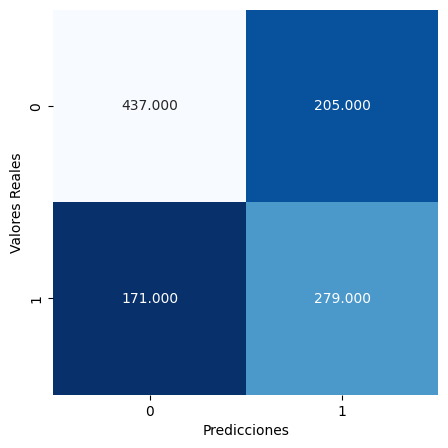

In [35]:
plt.figure(figsize=(5,5))
sns.heatmap(matriz_confusion, annot=True, fmt=".3f", square = True, cmap = 'Blues_r', cbar=False);
plt.ylabel('Valores Reales');
plt.xlabel('Predicciones');

### Precisión

$precision =  \frac{TP}{TP+FP} $

In [36]:
precision_score(predicciones, y)

0.5764462809917356

### Recall (Sensitividad)

$recall =  \frac{TP}{TP+FN} $

In [37]:
recall_score(predicciones, y)

0.62

### F1 score

In [38]:
f1_score(predicciones, y)

0.5974304068522484

### ROC Curve

In [39]:
fpr, tpr, tr = roc_curve(predicciones, y)

In [40]:
roc_score = roc_auc_score(predicciones, y)
roc_score

0.6503426791277258

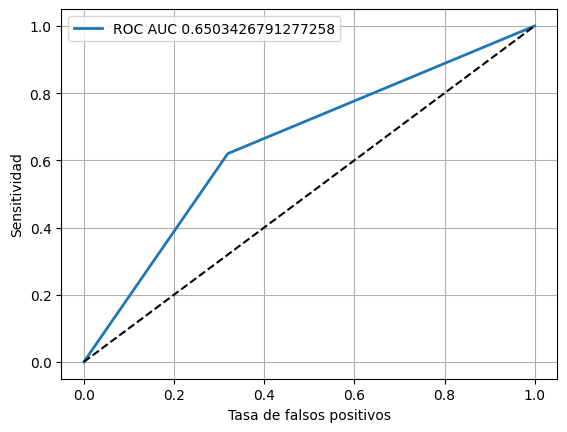

In [41]:
plt.plot(fpr, tpr, linewidth=2, label=f"ROC AUC {roc_score}")
plt.plot([0,1], [0,1], 'k--')#Diagonal
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Sensitividad')
plt.legend(loc='best')
plt.grid()
plt.show()

In [42]:
#ROC CURVE la linea indica la aleatoriedad. Entre más se acerca a uno mejor es el clasificador; entre mas bajo de la linea punteada es peor.

In [43]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [44]:
clf = DecisionTreeClassifier(max_depth=5)

In [45]:
clf.fit(x,y)

DecisionTreeClassifier(max_depth=5)

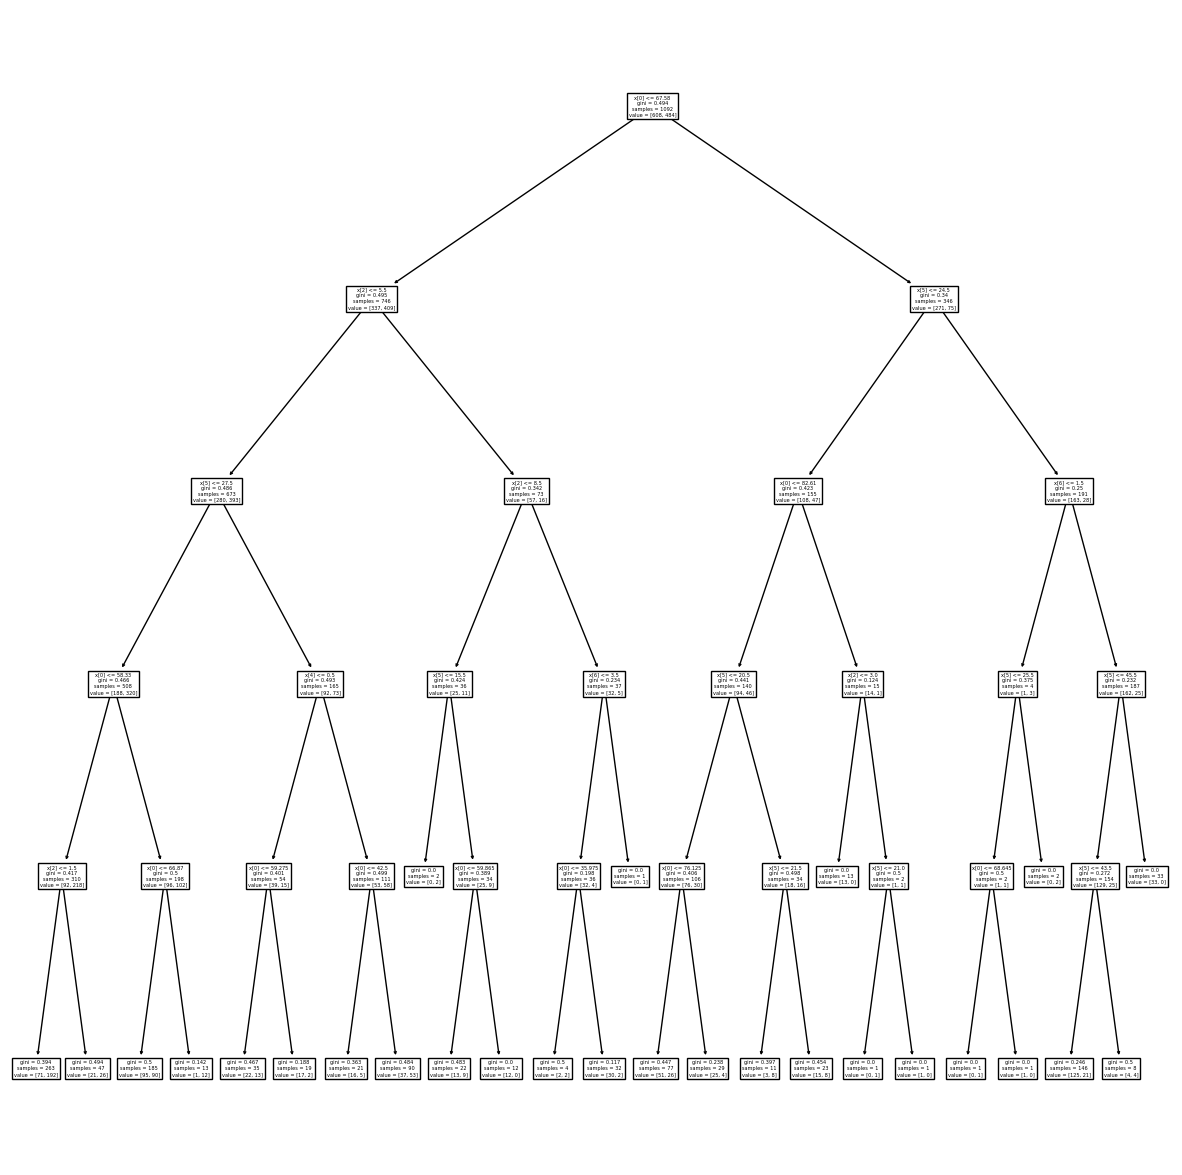

In [46]:
plt.figure(figsize=(15,15))
tree.plot_tree(clf)
plt.show()

In [47]:
predicciones_arbol = clf.predict(data_clinica[variables])

In [48]:
predicciones_arbol

array([1, 0, 0, ..., 0, 0, 0], dtype=int64)

Evaluando el modelo

In [49]:
mc_arbol = confusion_matrix(predicciones_arbol, y)

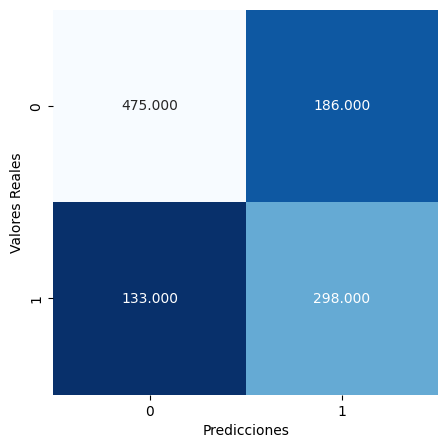

In [50]:
plt.figure(figsize=(5,5))
sns.heatmap(mc_arbol, annot=True, fmt=".3f", square = True, cmap = 'Blues_r', cbar=False);
plt.ylabel('Valores Reales');
plt.xlabel('Predicciones');

In [51]:
p = precision_score(predicciones_arbol, y)
r= recall_score(predicciones_arbol, y)
f1_arbol = f1_score(predicciones, y)

print(f"Precisión: {p*100:.2f} | Recall: {r*100:.2f} | f1 Score: {f1_arbol*100:.2f})")

Precisión: 61.57 | Recall: 69.14 | f1 Score: 59.74)
